<a href="https://colab.research.google.com/github/coldguto22/MiniIA/blob/main/dante_pearson_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Painel de Autoconsciência do Dante — Correlação de Pearson (implementação própria)

**Trabalho de FATEC — Otávio, Laisa e Jorge**

Modelo de Pearson implementado do zero (sem `scikit-learn`, sem `numpy.corrcoef`, sem `pandas.corr()`) aplicado a dados **reais** da memória persistente do Dante (MiniIA), com uma **métrica de interpretação própria do grupo** (inspirada na lógica de pequeno/médio/grande efeito de Jacob Cohen, mas não copiada de nenhuma tese) e um sistema de comparação e sugestão.

> Reescrito depois do retorno do professor: a primeira versão replicava fórmulas específicas da tese "Cognomia" (Santos, 2024) em vez de implementar o Pearson clássico e criar métricas próprias. Esta versão corrige isso.

## 1. Importações

In [2]:
import os
import zipfile
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

!pip install chromadb
import chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 75.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: opentelemetry-api
    Found ex

## 2. Carregar dados reais do Dante (ChromaDB)

Compacte a pasta `chroma_db/` do projeto Dante (não vai pelo GitHub — está no `.gitignore`) em `chroma_db.zip` e faça upload aqui.

In [3]:
from google.colab import files

CHROMA_DIR = "chroma_db"
dados_exemplo = False

if not os.path.isdir(CHROMA_DIR):
    print("Faça upload do arquivo chroma_db.zip (pasta chroma_db/ do projeto Dante compactada).")
    try:
        uploaded = files.upload()
        zip_name = list(uploaded.keys())[0]
        with zipfile.ZipFile(zip_name, "r") as z:
            z.extractall(".")
        print("Extraído com sucesso.")
    except Exception as e:
        print(f"Upload não realizado ({e}). Vou seguir com dados de EXEMPLO só para o pipeline funcionar.")
        dados_exemplo = True


Faça upload do arquivo chroma_db.zip (pasta chroma_db/ do projeto Dante compactada).


Saving chroma_db.zip to chroma_db.zip
Extraído com sucesso.


In [4]:
if not dados_exemplo:
    client = chromadb.PersistentClient(path=CHROMA_DIR)
    colecao = client.get_or_create_collection(name="memoria_da_ia")
    resultado = colecao.get(include=["documents", "metadatas", "embeddings"])
    documentos = resultado["documents"]
    metadatas = resultado["metadatas"]
    embeddings = resultado["embeddings"]
    print(f"{len(documentos)} memórias reais carregadas do Dante.")
else:
    documentos = [
        "Observação: vejo código Python na tela, estruturas que se repetem",
        "Pensamento: percebo padrões parecidos com memórias antigas sobre código",
        "Reflexão: código e memória parecem se conectar na minha forma de entender",
        "Diário: hoje observei código Python e senti curiosidade sobre estrutura e memória",
    ] * 8
    metadatas = [{"timestamp": datetime(2026,1,1,8+i%12,0,0).isoformat(),
                  "tipo": ["observacao_passiva","reflexao","diario"][i%3]} for i in range(len(documentos))]
    embeddings = np.random.RandomState(42).normal(size=(len(documentos), 32)).tolist()
    print("Usando DADOS DE EXEMPLO (substitua pelos dados reais do chroma_db).")


1182 memórias reais carregadas do Dante.


## 3. Variáveis reais extraídas da memória do Dante

- **tamanho_texto** — nº de caracteres do documento (proxy de "quanto o Dante elaborou")
- **hora_do_dia** — hora do registro (0–24, com minutos fracionados)
- **tipo_codigo** — codificação ordinal do tipo de registro (`observacao_passiva`, `reflexao`, `diario`)
- **grau_conexao_medio** — similaridade de cosseno média do embedding daquela memória com todas as outras (quão "integrada" à memória geral aquele registro está)

> 🔧 REVISÃO MANUAL: essas 4 variáveis são um ponto de partida real, mas se algum de vocês tiver acesso ao `dante.log` ou ao `diario.md`, dá pra somar variáveis novas (ex: quantidade de memórias recuperadas por ciclo, presença de entrada de diário naquele ciclo). Mais variáveis reais = análise mais rica, mas não é obrigatório.

In [15]:
def cosseno_similaridade_matriz(matriz_embeddings):
    """Similaridade de cosseno entre todos os pares de vetores, implementada
    manualmente via álgebra linear (produto escalar / normas) -- sem sklearn.pairwise."""
    m = np.array(matriz_embeddings, dtype=float)
    normas = np.linalg.norm(m, axis=1, keepdims=True)
    normas[normas == 0] = 1e-10
    m_normalizada = m / normas
    return m_normalizada @ m_normalizada.T


sim_matrix = cosseno_similaridade_matriz(embeddings)
np.fill_diagonal(sim_matrix, np.nan)
grau_conexao_medio = np.nanmean(sim_matrix, axis=1)

# Mapeamento por GRAU DE DEPENDÊNCIA DE MEMÓRIA ANTERIOR, não por ordem alfabética.
# Critério: 0 = registro não depende de memórias recuperadas para existir;
#           valores maiores = o texto é construído citando/conectando memórias já existentes.
# Baseado em como cada tipo é gerado no código do Dante (main.py, loop_dante.py,
# conversar.py, alimentar_memoria.py):
TIPO_PARA_DEPENDENCIA = {
    "conhecimento_fundacional": 0,
    "conhecimento_funadcional": 0,   # typo real do dataset -- mesmo conceito de "conhecimento_fundacional"
    "conhecimento_pessoal": 0,       # conhecimento inserido manualmente, não depende de memória recuperada
    "observacao_passiva": 0,
    "dialogo": 1,
    "interacao_usuario": 1,
    "pesquisa_autonoma": 1,
    "diario": 2,
    "reflexao": 3,
}

tipos_presentes = sorted(set(m.get("tipo", "desconhecido") for m in metadatas))
tipos_nao_mapeados = [t for t in tipos_presentes if t not in TIPO_PARA_DEPENDENCIA]
if tipos_nao_mapeados:
    print(f"⚠️ Tipos encontrados no chroma_db sem mapeamento definido: {tipos_nao_mapeados}")
    print("   Foram colocados no nível 0 por padrão -- revisem se isso faz sentido ou completem o dicionário acima.")

tipo_para_codigo = {
    t: TIPO_PARA_DEPENDENCIA.get(t, 0) for t in tipos_presentes
}

linhas = []
for doc, meta, conexao in zip(documentos, metadatas, grau_conexao_medio):
    ts = meta.get("timestamp")
    try:
        dt = datetime.fromisoformat(ts)
        hora_do_dia = dt.hour + dt.minute / 60
    except Exception:
        hora_do_dia = np.nan

    linhas.append({
        "tipo": meta.get("tipo", "desconhecido"),
        "tamanho_texto": len(doc),
        "hora_do_dia": hora_do_dia,
        "tipo_codigo": tipo_para_codigo.get(meta.get("tipo", "desconhecido"), -1),
        "grau_conexao_medio": conexao,
    })

df = pd.DataFrame(linhas).dropna()
print(f"{len(df)} registros válidos após limpeza.")
df.head(10)


1182 registros válidos após limpeza.


,tipo,tamanho_texto,hora_do_dia,tipo_codigo,grau_conexao_medio
0,reflexao,2943,9.816667,3,0.688366
1,reflexao,2305,9.850000,3,0.754609
2,dialogo,1293,9.900000,1,0.734867
3,reflexao,1551,9.933333,3,0.756808
4,reflexao,1450,9.950000,3,0.768427
5,reflexao,3376,9.966667,3,0.752542
6,reflexao,2663,9.983333,3,0.725173
7,reflexao,2377,10.000000,3,0.747715
8,diario,465,10.016667,2,0.669346
9,reflexao,1689,10.033333,3,0.757332


## 4. Coeficiente de Correlação de Pearson — modelo clássico, implementado do zero

$$ r_{xy} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2} \cdot \sqrt{\sum (y_i - \bar{y})^2}} $$

Esta é **a fórmula estatística real** do coeficiente de Pearson (não uma variante adaptada de nenhum artigo) — a mesma que qualquer disciplina de estatística ensina, calculada aqui manualmente: soma, média, covariância e desvio-padrão, sem nenhuma função pronta de correlação.

In [16]:
def pearson(x, y):
    """Coeficiente de Correlação de Pearson (fórmula clássica, centrada na média).
    Retorna NaN se alguma das variáveis for constante (desvio-padrão = 0), pois
    a correlação é matematicamente indefinida nesse caso -- tratamento explícito,
    não um contorno emprestado de outro lugar."""
    n = len(x)
    if n == 0:
        return float("nan")
    media_x = sum(x) / n
    media_y = sum(y) / n

    covariancia = sum((xi - media_x) * (yi - media_y) for xi, yi in zip(x, y))
    desvio_x = (sum((xi - media_x) ** 2 for xi in x)) ** 0.5
    desvio_y = (sum((yi - media_y) ** 2 for yi in y)) ** 0.5

    if desvio_x == 0 or desvio_y == 0:
        return float("nan")
    return covariancia / (desvio_x * desvio_y)


variaveis = ["tamanho_texto", "hora_do_dia", "tipo_codigo", "grau_conexao_medio"]

matriz_pearson = pd.DataFrame(index=variaveis, columns=variaveis, dtype=float)
for v1 in variaveis:
    for v2 in variaveis:
        matriz_pearson.loc[v1, v2] = pearson(df[v1].tolist(), df[v2].tolist())

print("Matriz de Correlação de Pearson (dados reais do Dante):")
matriz_pearson.round(3)


Matriz de Correlação de Pearson (dados reais do Dante):


,tamanho_texto,hora_do_dia,tipo_codigo,grau_conexao_medio
tamanho_texto,1.000,-0.089,-0.013,0.458
hora_do_dia,-0.089,1.000,-0.165,0.037
tipo_codigo,-0.013,-0.165,1.000,0.389
grau_conexao_medio,0.458,0.037,0.389,1.000


## 5. Métrica própria de interpretação (a parte mais "autoral" do trabalho)

Deixamos uma escala de exemplo (baseada nos limiares clássicos de Jacob Cohen para tamanho de efeito: 0,10 / 0,30 / 0,50 — pequeno / médio / grande), mas com **nomes e enquadramento inventados** para o contexto do Dante. Isso é só um rascunho para não travar o pipeline.

In [17]:

def interpretar_correlacao(r):
    """Métrica de interpretação PRÓPRIA do grupo para a força da correlação.
    Inspirada na lógica de pequeno/médio/grande efeito de Jacob Cohen (limiares
    0.10 / 0.30 / 0.50), mas com rótulos e enquadramento definidos pelo grupo
    para o contexto do Dante -- NÃO é a escala NCM de nenhuma tese."""
    if pd.isna(r):
        return "Indefinida", "Uma das variáveis não varia o suficiente para calcular correlação."

    r_abs = abs(r)
    if r_abs < 0.10:
        return "Ruído", "Praticamente nenhuma relação perceptível entre as variáveis."
    elif r_abs < 0.30:
        return "Padrão Sutil", "Relação fraca, mas presente -- vale observar ao longo do tempo."
    elif r_abs < 0.50:
        return "Padrão Emergente", "Relação moderada -- indício razoável de comportamento consistente."
    else:
        return "Padrão Consolidado", "Relação forte -- comportamento consistente e previsível entre as variáveis."


matriz_classificacao = matriz_pearson.applymap(lambda r: interpretar_correlacao(r)[0])
print("Matriz interpretada pela métrica própria do grupo:")
matriz_classificacao


Matriz interpretada pela métrica própria do grupo:


/tmp/ipykernel_556/3855176542.py:21: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matriz_classificacao = matriz_pearson.applymap(lambda r: interpretar_correlacao(r)[0])


,tamanho_texto,hora_do_dia,tipo_codigo,grau_conexao_medio
tamanho_texto,Padrão Consolidado,Ruído,Ruído,Padrão Emergente
hora_do_dia,Ruído,Padrão Consolidado,Padrão Sutil,Ruído
tipo_codigo,Ruído,Padrão Sutil,Padrão Consolidado,Padrão Emergente
grau_conexao_medio,Padrão Emergente,Ruído,Padrão Emergente,Padrão Consolidado


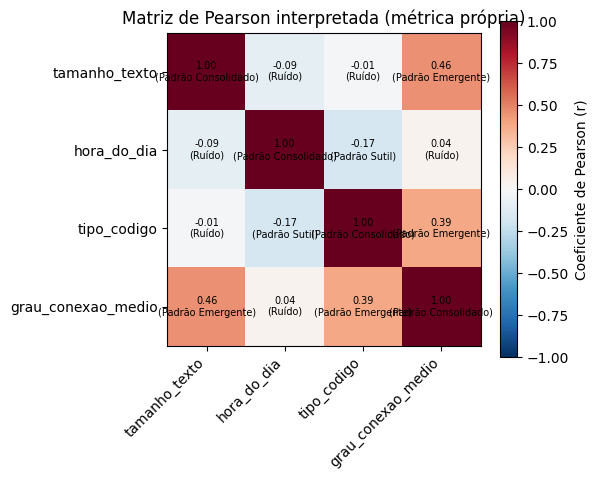

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))
cores = ax.imshow(matriz_pearson.astype(float), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(variaveis)))
ax.set_yticks(range(len(variaveis)))
ax.set_xticklabels(variaveis, rotation=45, ha="right")
ax.set_yticklabels(variaveis)

for i in range(len(variaveis)):
    for j in range(len(variaveis)):
        r = matriz_pearson.iloc[i, j]
        rotulo = matriz_classificacao.iloc[i, j]
        texto = "N/A" if pd.isna(r) else f"{r:.2f}\n({rotulo})"
        ax.text(j, i, texto, ha="center", va="center", fontsize=7)

plt.colorbar(cores, label="Coeficiente de Pearson (r)")
plt.title("Matriz de Pearson interpretada (métrica própria)")
plt.tight_layout()
plt.show()


## 6. Aplicação prática: Painel de Autoconsciência do Dante

Ideia da aplicação: usar a matriz de correlação para responder uma pergunta de produto real sobre o Dante -- **as reflexões do Dante estão de fato ancoradas no que ele observa, ou o comportamento é essencialmente aleatório?**

Para cada par de variáveis, o painel abaixo **compara** o resultado obtido e **sugere** uma leitura/ação prática.

In [19]:
sugestoes = {
    ("tamanho_texto", "grau_conexao_medio"): {
        "Padrão Consolidado": "Textos maiores estão fortemente ligados ao restante da memória -- o Dante parece 'elaborar mais quando tem mais para conectar'. Manter a estratégia atual de contexto na geração de reflexões.",
        "Padrão Emergente": "Há uma tendência moderada de textos maiores se conectarem mais à memória. Vale revisar o prompt de reflexão para reforçar conexões mesmo em textos curtos.",
        "Padrão Sutil": "A relação existe, mas é fraca -- não é o tamanho do texto que garante conexão com a memória.",
        "Ruído": "Tamanho do texto não prevê nada sobre conexão com a memória -- o comportamento parece mais aleatório do que gostaríamos para um sistema que se propõe reflexivo.",
        "Indefinida": "Não há variação suficiente numa das variáveis para avaliar essa relação.",
    },
    ("hora_do_dia", "tamanho_texto"): {
        "Padrão Consolidado": "O Dante escreve de forma consistentemente diferente conforme o horário -- pode valer ajustar o `INTERVALO_SEGUNDOS` ou o prompt por período do dia.",
        "Padrão Emergente": "Leve variação de tamanho por horário -- efeito provavelmente do conteúdo da tela, não do horário em si.",
        "Padrão Sutil": "Relação fraca -- horário não parece ser um fator relevante no comportamento do Dante.",
        "Ruído": "O horário não influencia o tamanho dos pensamentos -- comportamento estável ao longo do dia.",
        "Indefinida": "Não há variação suficiente numa das variáveis para avaliar essa relação.",
    },
    ("tipo_codigo", "grau_conexao_medio"): {
        "Padrão Consolidado": "O tipo de registro explica fortemente o grau de conexão -- reflexões e diários citam memórias antigas por design, e isso está sendo cumprido na prática.",
        "Padrão Emergente": "O tipo de registro tem influência parcial na conexão com a memória -- há espaço para reforçar isso no prompt de diário.",
        "Padrão Sutil": "Relação fraca entre tipo de registro e conexão -- o design não está se refletindo muito nos dados.",
        "Ruído": "O tipo de registro não distingue o grau de conexão -- reflexões podem estar tão desconectadas quanto observações passivas, o que é um problema de design a investigar.",
        "Indefinida": "Não há variação suficiente numa das variáveis para avaliar essa relação.",
    },
}

print("=" * 78)
print("PAINEL DE AUTOCONSCIÊNCIA DO DANTE -- comparação e sugestão")
print("=" * 78)
for (v1, v2), mapa in sugestoes.items():
    r = matriz_pearson.loc[v1, v2]
    classe = matriz_classificacao.loc[v1, v2]
    r_str = "N/A" if pd.isna(r) else f"{r:.3f}"
    print(f"\n[{v1} x {v2}]  r = {r_str}  ->  {classe}")
    print(f"  Sugestão: {mapa.get(classe, 'Sem sugestão cadastrada para esta classe')}")


PAINEL DE AUTOCONSCIÊNCIA DO DANTE -- comparação e sugestão

[tamanho_texto x grau_conexao_medio]  r = 0.458  ->  Padrão Emergente
  Sugestão: Há uma tendência moderada de textos maiores se conectarem mais à memória. Vale revisar o prompt de reflexão para reforçar conexões mesmo em textos curtos.

[hora_do_dia x tamanho_texto]  r = -0.089  ->  Ruído
  Sugestão: O horário não influencia o tamanho dos pensamentos -- comportamento estável ao longo do dia.

[tipo_codigo x grau_conexao_medio]  r = 0.389  ->  Padrão Emergente
  Sugestão: O tipo de registro tem influência parcial na conexão com a memória -- há espaço para reforçar isso no prompt de diário.


## 7. Conclusão

- O coeficiente de Pearson foi implementado com a **fórmula estatística clássica** (covariância / produto dos desvios-padrão), sem nenhuma biblioteca pronta, e com tratamento explícito do caso de variância zero.
- A métrica de interpretação (seção 5) é **proposta pelo grupo**, com Jacob Cohen citado apenas como inspiração conceitual de limiares, não como fonte das categorias.
- A aplicação prática (seção 6) é uma ideia própria (avaliar se o Dante reflete de forma ancorada ou arbitrária), com comparação e sugestão automáticas.